# Predicting Out-of-Stock Using Machine Learning
**Reference**: Andaur, J.M.R., Ruz, G.A. & Goycoolea, M. (2021). *Predicting Out-of-Stock Using Machine Learning: An Application in a Retail Packaged Foods Manufacturing Company.*

**Goal**: To replicate the paper's methodology which uses a standalone Random Forest classifier (System 1) and a 6-model voting ensemble (System 2) on engineered retail features to predict daily out-of-stock events.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading & Preprocessing

In [4]:
# Load data
train_df = pd.read_parquet('../data/top15_train.parquet')
test_df = pd.read_parquet('../data/top15_test.parquet')

def preprocess(df):
    df = df.copy()
    df['series_id'] = df['city_id'].astype(str) + '_' + df['store_id'].astype(str) + '_' + df['product_id'].astype(str)
    df = df.sort_values(['series_id', 'dt'])
    
    # Target variable: any stockout hour between 6-22
    df['target_oos'] = (df['stock_hour6_22_cnt'] > 0).astype(int)
    
    # Feature Engineering (Paper's engineered features)
    df['rolling_7d_sales'] = df.groupby('series_id')['sale_amount'].transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
    df['rolling_3d_sales'] = df.groupby('series_id')['sale_amount'].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    df['rolling_7d_stockouts'] = df.groupby('series_id')['stock_hour6_22_cnt'].transform(lambda x: x.shift(1).rolling(7, min_periods=1).sum())
    
    df['sales_momentum'] = df['sale_amount'] / (df['rolling_7d_sales'] + 1e-6)
    df['discount_flag'] = (df['discount'] < 1.0).astype(int)
    
    df['day_of_week'] = pd.to_datetime(df['dt']).dt.dayofweek
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    df['is_holiday'] = df['holiday_flag']
    df['is_activity'] = df['activity_flag']
    df['weather_stress'] = df['avg_temperature'] * df['precpt']
    
    df['prev_day_stockout'] = df.groupby('series_id')['target_oos'].shift(1)
    df['prev_2day_stockout'] = df.groupby('series_id')['target_oos'].shift(2)
    df['prev_week_stockout_rate'] = df.groupby('series_id')['target_oos'].transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
    
    return df.dropna()

print("Preprocessing train...")
train_df = preprocess(train_df)
print("Preprocessing test...")
test_df = preprocess(test_df)

features = ['rolling_7d_sales', 'rolling_3d_sales', 'rolling_7d_stockouts', 'sales_momentum', 
            'discount_flag', 'day_of_week', 'is_weekend', 'is_holiday', 'is_activity', 
            'weather_stress', 'prev_day_stockout', 'prev_2day_stockout', 'prev_week_stockout_rate']

X_train, y_train = train_df[features], train_df['target_oos']
X_test, y_test = test_df[features], test_df['target_oos']

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Train OOS events: {y_train.sum()} ({y_train.mean():.1%})")

Preprocessing train...
Preprocessing test...
Train size: 170893, Test size: 30433
Train OOS events: 91493 (53.5%)


## 2. System 1: Balanced Random Forest

=== Random Forest Results ===
F1-Score: 0.6038
Recall:   0.5587
MAE:      0.3203
ROC-AUC:  0.7281


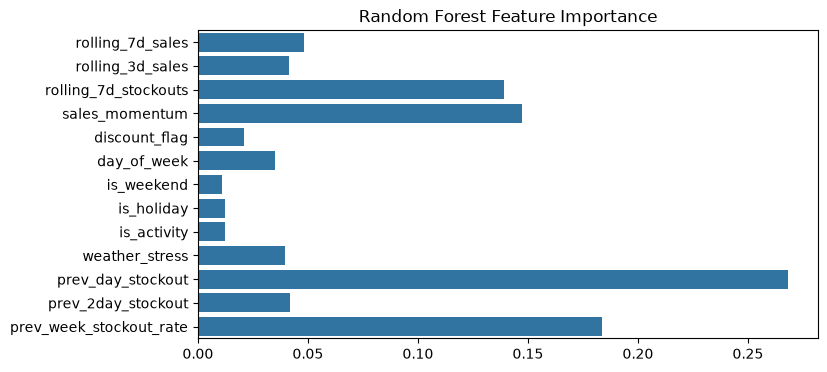

CPU times: user 5min 41s, sys: 16.8 s, total: 5min 58s
Wall time: 40.5 s


In [5]:
%%time
from sklearn.metrics import f1_score, recall_score, mean_absolute_error

rf = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=5, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

f1 = f1_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
mae = mean_absolute_error(y_test, y_pred_rf)

print("=== Random Forest Results ===")
print(f"F1-Score: {f1:.4f}")
print(f"Recall:   {recall:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_rf):.4f}")

plt.figure(figsize=(8,4))
sns.barplot(x=rf.feature_importances_, y=features)
plt.title('Random Forest Feature Importance')
plt.show()

## 3. System 2: 6-Classifier Ensemble

In [ ]:
%%time
# Scale data for distance/gradient based models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define base models
m1 = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
m2 = GradientBoostingClassifier(n_estimators=200, max_depth=5, subsample=0.8, random_state=42)
m3 = LogisticRegression(class_weight='balanced', max_iter=1000, C=0.1)
m4 = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=200, early_stopping=True, random_state=42)
m5 = KNeighborsClassifier(n_neighbors=7, weights='distance', n_jobs=-1)

# Soft voting ensemble
ensemble = VotingClassifier(estimators=[
    ('rf', m1), ('gbm', m2), ('lr', m3), ('mlp', m4), ('knn', m5)
], voting='soft', n_jobs=-1)

ensemble.fit(X_train_scaled, y_train)

y_pred_ens = ensemble.predict(X_test_scaled)
y_prob_ens = ensemble.predict_proba(X_test_scaled)[:, 1]

f1_ens = f1_score(y_test, y_pred_ens)
recall_ens = recall_score(y_test, y_pred_ens)
mae_ens = mean_absolute_error(y_test, y_pred_ens)

print("=== Ensemble Results ===")
print(f"F1-Score: {f1_ens:.4f}")
print(f"Recall:   {recall_ens:.4f}")
print(f"MAE:      {mae_ens:.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_ens):.4f}")